# EVASPA Evapotranspiration processing

In [1]:
from __future__ import annotations

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
from pprint import pprint

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.colors import ListedColormap

In [4]:
from evaspa import ef, filter, merging, seb
from evaspa.config import ParamsConfig

### Common

In [5]:
if os.environ["EVASPA_TEST_DATA_PATH"] is None:
    msg = "Variable EVASPA_TEST_DATA_PATH must be set"
    raise ValueError(msg)

In [6]:
def plot_rgb(data: xr.Dataset, bands: list[str] | None = None):
    if bands is None:
        bands = ["red", "green", "blue"]
    rgb = xr.DataArray(
        np.dstack(
            (data[bands[0]].data, data[bands[1]].data, data[bands[2]].data)
        ),
        data.coords.assign(band=["r", "g", "b"]),
        dict(data.sizes, band=3),
    )
    rgb.plot.imshow(  # type: ignore
        rgb="band",
        vmin=rgb.quantile(0.01),
        vmax=rgb.quantile(0.99),
    )
    plt.title("RGB")


def plot_band(data: xr.Dataset, band: str):
    data[band].plot.imshow(  # type: ignore
        vmin=data[band].quantile(0.01),
        vmax=data[band].quantile(0.99),
    )


def plot_mask(data: xr.Dataset, mask: str, invert=False):
    cmap = [(0.0, 0.0, 0.0, 0.0)]
    if len(np.unique(data[mask].data)) > 1:
        cmap = [(1.0, 0.0, 0.0, 1.0), (0.0, 0.0, 0.0, 0.0)]
    if invert:
        cmap = cmap[::-1]
    valid_cmap = ListedColormap(cmap)
    data[mask].plot(cmap=valid_cmap, add_colorbar=False)


def plot(
    data: xr.Dataset,
    var_name: str | None = None,
    model: ef.EFModel | None = None,
    save: bool = False,
):
    """
    Plot
    """
    # dimensions
    # gridspec inside gridspec
    fig = plt.figure(constrained_layout=True, figsize=(4, 3))

    ax = plt.gca()

    if var_name is None and model is None:
        msg = "Provide either var_name or model"
        raise ValueError(msg)
    lst = data["lst"].data

    if var_name is not None:
        var = data[var_name].data
        # plot all points
        ax.scatter(var, lst, s=20, alpha=1, color="moccasin", clip_on=False)

    # plot edges
    elif model is not None:
        var_name = model.var
        var = data[model.var].data
        # plot all points
        ax.scatter(var, lst, s=20, alpha=1, color="moccasin", clip_on=False)
        # edges coordinates
        var_max = np.round(np.ceil(np.nanmax(var) * 10) / 10, decimals=1)
        var_min = np.round(np.floor(np.nanmin(var) * 10) / 10, decimals=1)

        var_arr = np.linspace(var_min, var_max, num=20)
        tw_arr = model.twet(var_arr)
        td_arr = model.tdry(var_arr)

        ax.plot(
            var_arr,
            td_arr,
            color="tab:red",
            linewidth=3,
            label="dry edge",
            zorder=1,
        )
        ax.plot(
            var_arr,
            tw_arr,
            color="tab:blue",
            linewidth=3,
            label="wet edge",
            zorder=1,
        )

    # Labels
    ax.set_xlabel(var_name)
    ax.set_ylabel("Land Surface Temperature K")

    # title
    ax.set_title("Evaporative fraction method", fontsize=12)

    # savefig
    if save:
        destfile = "ef.png"
        fig.savefig(destfile)

    plt.show()

### Input

In [7]:
import sys

sys.path.append("..")
from tests.test_seb import setup_data

Data

In [8]:
data = setup_data(nb=2)
# create cloud
data["cloud"] = xr.where(data["valid"], 0, 1)

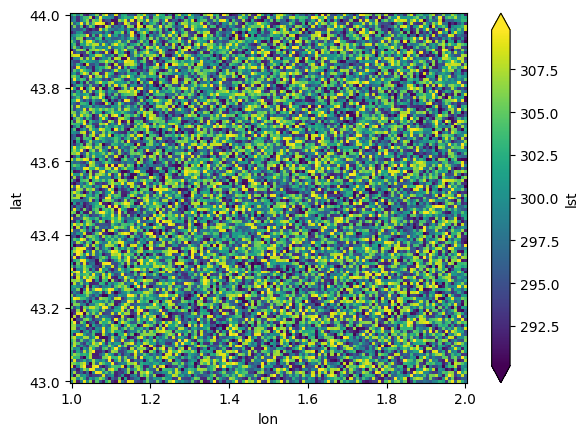

In [9]:
plot_band(data, band="lst")

Configuration

In [10]:
params = {
    "filtering": {"cloud": "cloud"},
    "ef": {
        "check": {"threshold": 0.02},
        "models": "default_evaspa",
        "options": {"selection": False, "merging": "mean"},
    },
    "seb": {},
}

## Run step by step 

Validate parameters config

In [11]:
# Validate parameters config
params_config = ParamsConfig.model_validate(params)

In [12]:
params_config

ParamsConfig(filtering=FilterConfig(cloud='cloud', water=None, qa=None, zones=None, cover=None, config=FilterParams(cloud=0, water=0, qa=0, zones=0, cover=[10, 60, 80])), ef=EFConfig(models=[EFModelConfig(name='model1', dry_edge=EdgeConfig(type='LinearEdge', config={'interval_type': 'size', 'interval_nb': 20, 'percentile': [98, 100], 'selection': 'median'}), wet_edge=EdgeConfig(type='LinearEdge', config={'interval_type': 'size', 'interval_nb': 20, 'percentile': [0, 2], 'selection': 'median'}), var='albedo'), EFModelConfig(name='model2', dry_edge=EdgeConfig(type='LinearEdge', config={'interval_type': 'density', 'interval_nb': 20, 'percentile': [95, 100], 'selection': 'median'}), wet_edge=EdgeConfig(type='FlatEdge', config={'selection': 'min'}), var='lai')], options=EFOptionsConfig(selection=False, merging=<MergeMethod.MEAN: 'mean'>), check=EFCheckConfig(threshold=0.02)), seb=SEBConfig(use_topo=False, g_models=['kustas']))

In [13]:
pprint(params_config.model_dump(), sort_dicts=False)

{'filtering': {'cloud': 'cloud',
               'water': None,
               'qa': None,
               'zones': None,
               'cover': None,
               'config': {'cloud': 0,
                          'water': 0,
                          'qa': 0,
                          'zones': 0,
                          'cover': [10, 60, 80]}},
 'ef': {'models': [{'name': 'model1',
                    'dry_edge': {'type': 'LinearEdge',
                                 'config': {'interval_type': 'size',
                                            'interval_nb': 20,
                                            'percentile': [98, 100],
                                            'selection': 'median'}},
                    'wet_edge': {'type': 'LinearEdge',
                                 'config': {'interval_type': 'size',
                                            'interval_nb': 20,
                                            'percentile': [0, 2],
                                  

Filter

In [14]:
# Filter data
data["valid"] = filter.determine_valid_pixels(
    data, **params_config.filtering.model_dump()
)

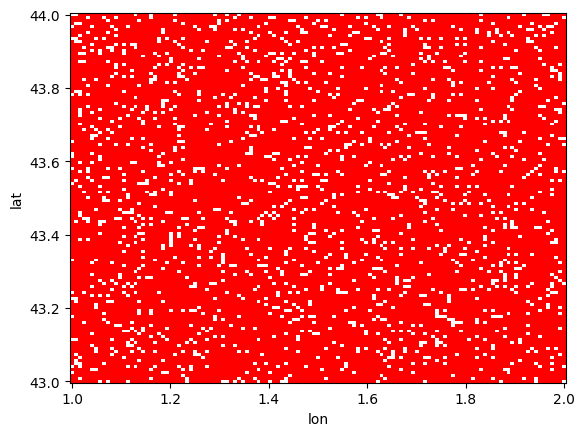

In [15]:
plot_mask(data=data, mask="valid", invert=True)

Check variability

In [16]:
ef.check_variability(
    data["lst"], mask=data["valid"], **params_config.ef.check.model_dump()
)

True

Compute EF

In [17]:
models, options = ef.initialize(params_config.ef.model_dump())

In [18]:
ef_xr, ef_inst_xr = ef.run(
    models, data, mask="valid", **params_config.ef.options.model_dump()
)

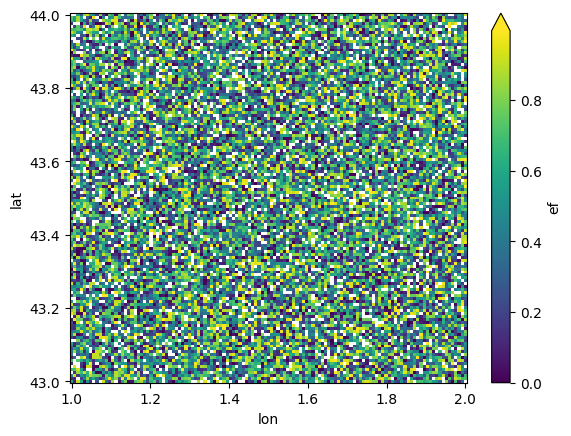

In [19]:
plot_band(ef_inst_xr, band="ef")

Compute LE

In [20]:
rn_xr = seb.create_net_radiation(data)

In [21]:
g_xr = seb.create_gflux(data, rn_xr)

In [22]:
le_xr = seb.create_le(ef_xr, rn_xr, g_xr)

In [23]:
le_xr

<xarray.Dataset> Size: 3MB
Dimensions:                     (lon: 125, lat: 125)
Coordinates:
  * lon                         (lon) float32 500B 1.0 1.008 1.016 ... 1.992 2.0
  * lat                         (lat) float32 500B 43.0 43.01 ... 43.99 44.0
Data variables: (12/24)
    model1_rn_rn_kustas         (lon, lat) float64 125kB 0.6013 2.964 ... -13.77
    model1_rn_rn_su             (lon, lat) float64 125kB 0.7327 2.376 ... -23.8
    model1_rn_rn_choudhury      (lon, lat) float64 125kB 1.004 3.2 ... -24.38
    model1_rn_rn_1_kustas       (lon, lat) float64 125kB 0.3212 2.957 ... -14.27
    model1_rn_rn_1_su           (lon, lat) float64 125kB 0.5414 2.361 ... -23.88
    model1_rn_rn_1_choudhury    (lon, lat) float64 125kB 0.9966 3.197 ... -24.44
    ...                          ...
    model2_rn_1_rn_kustas       (lon, lat) float64 125kB 1.262 2.602 ... -12.57
    model2_rn_1_rn_su           (lon, lat) float64 125kB 1.391 2.094 ... -22.49
    model2_rn_1_rn_choudhury    (lon, lat) float64 125kB 1.657 2.806 ... -23.06
    model2_rn_1_rn_1_kustas     (lon, lat) float64 125kB 0.9876 2.597 ... -13.06
    model2_rn_1_rn_1_su         (lon, lat) float64 125kB 1.203 2.081 ... -22.57
    model2_rn_1_rn_1_choudhury  (lon, lat) float64 125kB 1.649 2.803 ... -23.11
Attributes:
    crs:        None
    transform:  None

Merge LE

In [24]:
le_inst = merging.merge_to_dataset(le_xr, method=merging.MergeMethod.MEAN)

In [25]:
le_inst

<xarray.Dataset> Size: 126kB
Dimensions:  (lon: 125, lat: 125)
Coordinates:
  * lon      (lon) float32 500B 1.0 1.008 1.016 1.024 ... 1.976 1.984 1.992 2.0
  * lat      (lat) float32 500B 43.0 43.01 43.02 43.02 ... 43.98 43.99 44.0
Data variables:
    merged   (lon, lat) float64 125kB 1.032 2.671 63.15 ... 66.74 31.75 -20.11
Attributes:
    crs:        None
    transform:  None

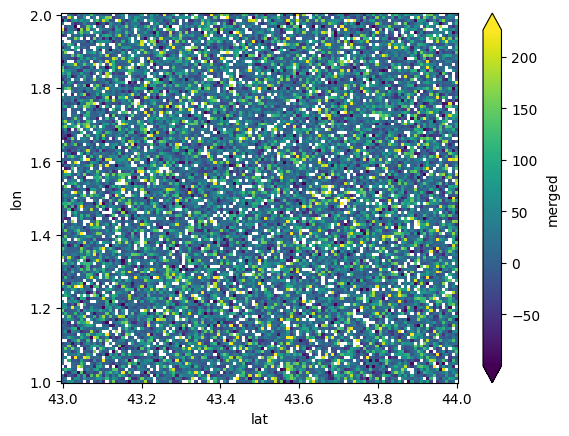

In [26]:
plot_band(le_inst, band="merged")